In [46]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from BaselineRemoval import BaselineRemoval
import matplotlib.pyplot as plt
import glob
import seaborn as sns
import tqdm as tqdm

In [47]:
# def process_data(fp):
#     l = [pd.read_csv(filename,header=None,delimiter = "\t") for filename in glob.glob(fp)]
#     data = pd.concat(l, ignore_index=True)
#     data.columns = ["positionX", "positionY", "Wavenumber", "Counts"]
#     data.drop(data.columns[[0, 1]], axis = 1, inplace = True)
#     n =1300
#     data_separate = pd.DataFrame(np.hstack(np.vsplit(data.values, len(data) // n)))
#     data_separate.columns = data_separate.columns.map(lambda c: chr(c +ord('A')))
#     col_to_drop = data_separate.columns[np.array([i for i in
#     range(data_separate.shape[1]) if i != 0 and i%2 != 1])]
#     rslt_df = data_separate.drop(col_to_drop, axis=1)
#     rslt_df.rename(columns = {'A':'Wavenumber'}, inplace = True)

#     #Cosmic ray removal
#     #function
#     def modified_z_score(intensity):
#         median_int = np.median(intensity)
#         mad_int = np.median([np.abs(intensity - median_int)])
#         modified_z_scores = 0.6745 * (intensity - median_int) / mad_int
#         return modified_z_scores

#     def fixer(y,m):
#         threshold = 5 # binarization threshold.
#         spikes = abs(np.array(modified_z_score(np.diff(y)))) > threshold
#         y_out = y.copy() # So we don’t overwrite y
#         for i in np.arange(len(spikes)):
#             if spikes[i] != 0: # If we have an spike in position i
#                 w = np.arange(i-m,i+1+m) # we select 2 m + 1 points around our spike
#                 w2 = w[spikes[w] == 0] # From such interval, we choose the ones which are not spikes
#                 y_out[i] = np.mean(y[w2]) # and we average their values
#         return y_out

#     # Transform the data to a numpy array
#     #data1 = rslt_df.drop(columns = ['Wavenumber'])
#     MASTER = []
#     for i in rslt_df.columns:
#         intensity = rslt_df[i].values.tolist()
#         intensity = np.array(intensity)
#         fixed_intensity = fixer(intensity,m=7)
#         MASTER.append(fixed_intensity)

#     df = pd.DataFrame(MASTER)
#     result = df.transpose()
#     result.columns = result.columns.map(lambda c: chr(c + ord('A')))
#     #result.to_excel('M1 cosmic ray removal.xlsx', index=False)

#     #baseline removal
#     data1 = result.drop(columns = ['A'])
#     cols = list(data1.columns.values)
#     #ind = data. iloc[:, 0]
#     #ind_list = ind.tolist()

#     Master2=[]

#     for i in data1.columns:
#         temp = data1[i].values.tolist()
#         baseObj=BaselineRemoval(temp)
#         Zhangfit_output=baseObj.ZhangFit()
#         Master2.append(Zhangfit_output)

#     output = pd.DataFrame (Master2)

#     reshape = np.transpose(output)

#     #reshape.to_excel('M1 baseline correction.xlsx', index=False)

#     #Normalization
#     x = reshape.values #returns a numpy array
#     min_max_scaler = preprocessing.MinMaxScaler()
#     x_scaled = min_max_scaler.fit_transform(x)
#     data_normalized = pd.DataFrame(x_scaled, columns = [cols])

#     #output
#     new_df = rslt_df['Wavenumber']
#     a = new_df.to_frame(name='Wavenumber')

#     frame = pd.concat([a,data_normalized], axis = 1)
#     # frame.to_excel('/Users/Nikki/Desktop/Machine LearningDemo/Control/Control - Full Processing.xlsx', index=False)
#     return frame

In [48]:
def no_processing(data_paths, labels, delim=","):
    data = pd.DataFrame()
    for data_path, label in zip(data_paths, labels):    
        l = [pd.read_csv(filename,header=None,index_col=0, names=[label], delimiter = delim) for filename in glob.glob(data_path)]
        new_data = pd.concat(l, ignore_index=False, axis=1)
        data = pd.concat([data, new_data], ignore_index=False, axis=1)
    return data.T

In [49]:
fps = ["./data/exp1/0/*.csv", "./data/exp1/1/*.csv", "./data/exp1/3/*.csv"]
labels = ["0 cm", "1 cm", "3 cm"]

In [50]:
data = no_processing(fps, labels)
cols_to_drop = [col for col in data.columns if col <= 4500]
data = data.drop(columns=cols_to_drop)

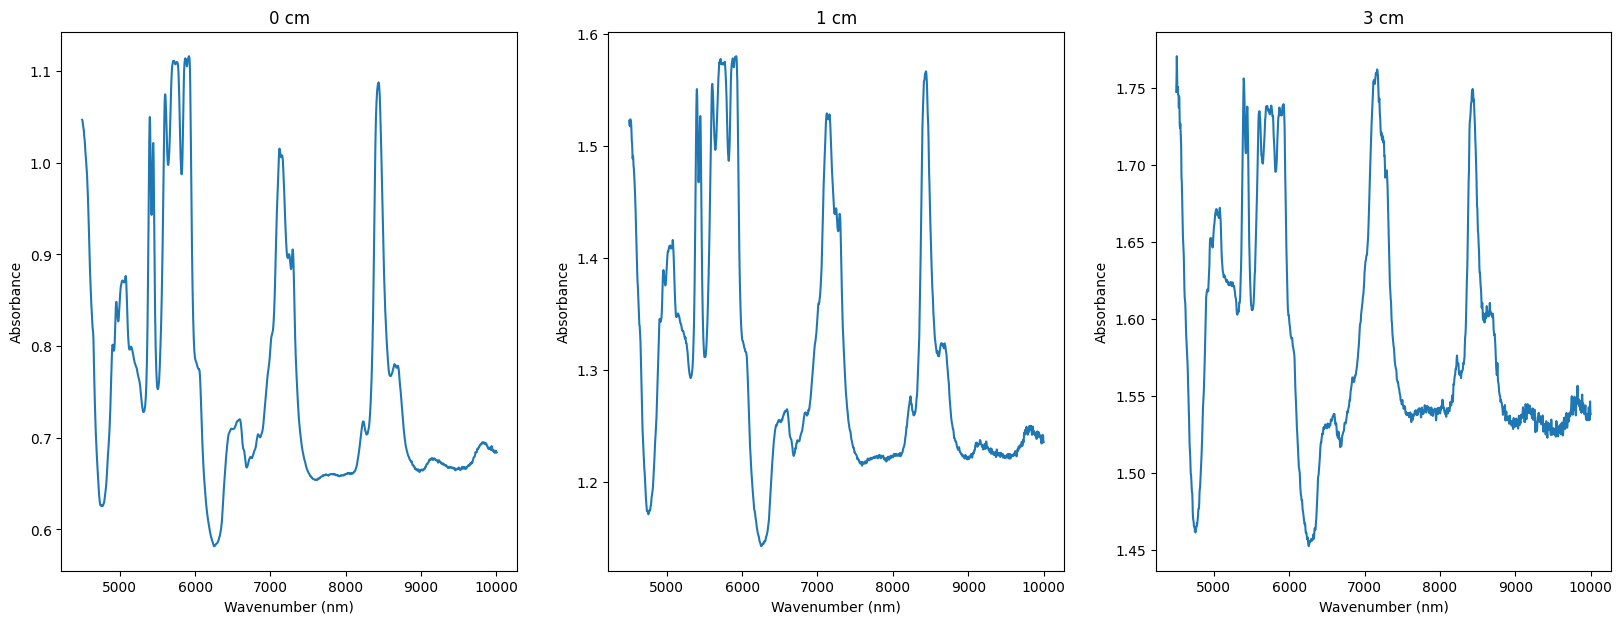

In [56]:
fig, axs = plt.subplots(1,3, figsize=(20,7))
for ax, label in zip(axs.flatten(), labels):
    mean_data = data.loc[label].mean()
    ax.plot(data.columns, mean_data, label=label)
    ax.set_xlabel("Wavenumber (nm)")
    ax.set_ylabel("Absorbance")
    ax.set_title(label)

plt.show()

In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#read the data
n = len(data.columns)
X_features = data.iloc[:, 1:n]
y_label = data.iloc[:,0]

#convert the features into the 2 top features
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_features)
#principalDf = pd.DataFrame(data = principalComponents, columns =['principal component 1', 'principal component 2'])
#principalDf.head(5)
#data[['group']].head()
#finalDf = pd.concat([principalDf, data[['group']]], axis = 1)
df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = principalComponents[:,0]
df["comp-2"] = principalComponents[:,1]
scatter_plot = sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
palette=sns.color_palette("hls", 4),data=df).set(title="PCA - Full Processing")
#plt.savefig('PCA – No Processing.png')

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
#t-SNE
from sklearn.manifold import TSNE
from numpy import reshape
import seaborn as sns

tsne = TSNE(n_components=2, verbose=1, random_state=123)
z = tsne.fit_transform(X_features)
df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = z[:,0]
df["comp-2"] = z[:,1]
scatter_plot = sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
palette=sns.color_palette("hls", 4),
data=df).set(title="T-SNE - No Processing")

In [ ]:
#phate
import phate
phate_op = phate.PHATE()
phate_op.set_params(knn=10, decay=15, t=12)#knn : Number of nearest neighbors (default: 5).
#Increase this (e.g. to 20) if your PHATE embedding appears verydisconnected.
#You should also consider increasing knn if your dataset is extremely large(e.g. >100k cells)
#decay : Alpha decay (default: 15). Decreasing decay increases connectivity on the graph,
#increasing decay decreases connectivity.
#This rarely needs to be tuned. Set it to None for a k-nearest neighbors kernel.

data_phate = phate_op.fit_transform(X_features)
result_phate = pd.DataFrame()
result_phate["y"] = y_label
result_phate["PHATE-1"] = data_phate[:,0]
result_phate["PHATE-2"] = data_phate[:,1]
sns.scatterplot(x="PHATE-1", y="PHATE-2", hue=result_phate.y.tolist(),
palette=sns.color_palette("hls", 4),data=result_phate).set(title="PHATE - No Processing")
plt.savefig('PHATE – No Processing.png')

In [ ]:
#UMAP
from numpy import reshape
import seaborn as sns
import umap
# import umap.plot

plt.rcParams['figure.figsize'] = (8,5)
#mapper = umap.UMAP().fit(X_features)
#umap.plot.points(mapper, labels=y_label)
embedding = umap.UMAP(n_neighbors=10,
min_dist=0.5,n_components=2,
metric='correlation').fit_transform(X_features)
result = pd.DataFrame()
result["y"] = y_label
result["UMAP-1"] = embedding[:,0]
result["UMAP-2"] = embedding[:,1]
sns.scatterplot(x="UMAP-1", y="UMAP-2", hue=result.y.tolist(),
palette=sns.color_palette("hls", 4),
data=result).set(title="UMAP No Processing")